# Assignment 1. Machine Learning and Deep Learning
#### Maayan Sarig & Omri Triff

This assignment consists of two parts:

**Part 1: Student Performance Prediction**
- We will build models to predict student performance using the "Student Performance Dataset", which includes student grades, demographic, social and school related features collected through school reports and questionnaires.
- You can read more about this dataset at [the UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/320/student+performance).
- In the first section, you will write a linear regression model to predict students' grades at the end of the year.
- In the second section, you will build a classifier to predict if a student's performance will be above average.

**Part 2: Music Century Classification**
- We will construct models to predict the century in which a music piece was released using the "YearPredictionMSD Data Set", derived from the Million Song Dataset.
- Make sure you download the version of the dataset from the moodle and not from UCI.
- Relevant links:
  - https://archive.ics.uci.edu/ml/datasets/yearpredictionmsd
  - http://millionsongdataset.com/pages/tasks-demos/#yearrecognition
- You will implement logistic regression from scratch using gradient descent.
- You will then see how the same task can be accomplished using PyTorch.

## Files Structure

The assignment includes:
1. This notebook file (ML_DL_Assignment1.ipynb)
2. The student performance dataset file (student-mat.csv)
3. The year prediction dataset file (YearPredictionMSD.csv)

You will mount and load the datasets from Google Drive. Make sure you have both dataset files in the same directory in your Google Drive.

## Submission Requirements

When you are finished with the assignment, submit This notebook file, including your code and presented results. Make sure all results are visible and all code cells have been executed in order.

## Important Note

In **Part 2** (Music Century Classification), until Section 2.8, you are **not allowed to import additional packages (especially not PyTorch)**. One of the objectives is to understand how the training procedure actually operates before working with PyTorch's autograd engine. Importing the PyTorch package before Section 2.8 will deduct from your points.

In [1]:
import pandas
import numpy as np
import matplotlib.pyplot as plt
import sys


---
# Part 1. Student Performance Prediction

## 1. The Data

### 1.1 Load your dataset from Google Drive

Start by setting up a Google Colab notebook in which to do your work.
You might find this link helpful:

- https://colab.research.google.com/github/googlecolab/colabtools/blob/master/notebooks/colab-github-demo.ipynb

To process and read the data, we use the popular `pandas` package for data analysis.

Now that your notebook is set up, we can load the data into the notebook. You will need to upload the "student-mat.csv" dataset to a directory in Google Drive and mount your Google Drive to the Colab notebook.

Here are some resources to help you get started:

[http://colab.research.google.com/notebooks/io.ipynb](https://colab.research.google.com/notebooks/io.ipynb)

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')  # Your Google Drive will be mounted to /content/gdrive

drive_path = '/content/gdrive/MyDrive/Intro_to_Deep_Learning/Assignment1/' # TODO - UPDATE ME WITH THE TRUE PATH! - Mayaan path /content/gdrive/My Drive/Intro_to_Deep_Learning/Assignment1/

print("looking for dataset in: "+drive_path+'student-mat.csv')
df = pandas.read_csv(drive_path+'student-mat.csv')
df = df.sample(frac=1) # This line scrambles the order of the dataframe

Mounted at /content/gdrive
looking for dataset in: /content/gdrive/MyDrive/Intro_to_Deep_Learning/Assignment1/student-mat.csv


In [3]:
import os

# Adjust this path if you want to start exploring from a specific subfolder
base_path = '/content/gdrive/My Drive/'

print(f"Listing contents of: {base_path}")

try:
    # List all files and directories in the specified path
    for item in os.listdir(base_path):
        print(item)
except FileNotFoundError:
    print(f"Error: The path '{base_path}' was not found. Please ensure your Google Drive is mounted and the path is correct.")
except Exception as e:
    print(f"An error occurred: {e}")

Listing contents of: /content/gdrive/My Drive/
בגרות בכלכלה (Autosaved) (4) (2)עמרי טריף 1.docx
00473056_206585051_6816_290120200925.pdf
00473056_206585051_6816_290120200925.gdoc
Untitled form.gform
image3.jpeg
91230.zip
אווירה.xlsx
אווירה.gsheet
טופס ללא כותרת (2).gform
טופס ללא כותרת (1).gform
image1.jpeg
image0.jpeg
IMG_0743 (1).JPG
IMG_0748 (1).JPG
IMG_0750 (1).JPG
IMG_0740 (1).JPG
IMG_0741 (1).JPG
IMG_0755 (1).JPG
IMG_0738 (1).JPG
IMG_0788 (1).JPG
IMG_0739 (1).JPG
IMG_0749 (1).JPG
IMG_0742 (1).JPG
IMG_0744 (1).JPG
IMG_0752 (1).JPG
IMG_0754 (1).JPG
IMG_0753 (1).JPG
IMG_0747 (1).JPG
IMG_0751 (1).JPG
IMG_0746 (1).JPG
IMG_0745 (1).JPG
IMG_0737 (1).JPG
IMG_0756 (1).JPG
IMG_0750.JPG
IMG_0743.JPG
IMG_0904.JPG
IMG_0740.JPG
IMG_0788.JPG
IMG_0749.JPG
IMG_0752.JPG
IMG_0756.JPG
IMG_0747.JPG
IMG_0737.JPG
IMG_0745.JPG
IMG_0751.JPG
IMG_0754.JPG
IMG_0744.JPG
IMG_0741.JPG
IMG_0757.JPG
IMG_0748.JPG
IMG_0742.JPG
IMG_0738.JPG
IMG_0739.JPG
IMG_0746.JPG
IMG_0755.JPG
IMG_0753.JPG
D16AD1BF-EB6E-4A41-A4E4

After running the code above, you should see a list of files and folders in your `My Drive`. Look for the folder where you placed `student-mat.csv`. For example, if it's in a folder called `Intro_to_Deep_Learning`, your `drive_path` should be adjusted to something like `'/content/gdrive/My Drive/Intro_to_Deep_Learning/Assignment1/'` (if `Assignment1` is also a subfolder).

Once you've identified the correct path, you can then modify the `drive_path` in the original cell `ac09b5fe` to the correct value.

Now that the data is loaded to your Colab notebook, you should be able to display the Pandas DataFrame `df` as a table:

In [4]:
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
332,GP,F,17,U,GT3,A,3,3,health,other,...,3,3,3,1,3,3,6,8,7,9
86,GP,F,15,R,GT3,T,3,3,services,services,...,4,2,1,2,3,3,8,10,10,10
131,GP,F,16,U,GT3,A,2,2,other,other,...,3,3,4,1,1,4,0,12,13,14
172,MS,M,17,R,GT3,T,4,3,services,other,...,4,5,5,1,3,2,4,13,11,11
102,GP,M,17,U,GT3,T,1,3,at_home,services,...,5,3,3,1,4,2,2,10,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
324,GP,M,17,R,GT3,T,2,2,other,other,...,4,5,2,1,1,1,4,11,11,11
85,GP,F,18,U,LE3,T,2,2,other,other,...,4,3,3,1,1,2,0,8,8,0
15,GP,M,17,U,GT3,T,3,3,other,other,...,4,3,4,1,4,4,4,6,5,6
115,GP,F,17,U,GT3,T,3,4,services,other,...,4,4,5,1,3,5,16,16,15,15


Notice that the data consists of multiple types. There are numeric columns such as 'age','freetime' and 'G3' but there are also a few categorical columns for example 'school','address','Mjob' etc. Since we want to use a numeric estimator we need all our data to be numeric. We can use indicators to translate the categories into numeric values. In the pandas library it is done using the [get_dummies](https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html) function.

Notice that in this assignment we will not be using any multiple category columns (to simplify the task a bit) so we remove the columns 'Mjob', 'Fjob', 'reason' and 'guardian'.

In [5]:
df_no_multi_categorical = df.drop(["Mjob","Fjob","reason","guardian"],axis=1)
df_numerical = pandas.get_dummies(df_no_multi_categorical, drop_first=True)



```
# This is formatted as code
```

Notice how each categorical column has been converted to a binary numerical value.

In [6]:
df_numerical

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,famsize_LE3,Pstatus_T,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
332,17,3,3,1,2,0,3,3,3,1,...,False,False,False,True,False,False,False,True,True,True
86,15,3,3,2,3,2,4,2,1,2,...,False,True,False,True,True,True,True,True,True,True
131,16,2,2,1,2,0,3,3,4,1,...,False,False,True,True,True,False,True,True,True,False
172,17,4,3,2,2,0,4,5,5,1,...,False,True,False,True,True,True,False,True,True,True
102,17,1,3,1,1,0,5,3,3,1,...,False,True,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
324,17,2,2,2,2,0,4,5,2,1,...,False,True,False,True,True,True,True,True,True,False
85,18,2,2,1,2,0,4,3,3,1,...,True,True,False,False,False,True,False,True,True,True
15,17,3,3,1,2,0,4,3,4,1,...,False,True,False,False,False,True,False,True,True,False
115,17,3,4,1,3,0,4,4,5,1,...,False,True,False,False,False,False,True,True,True,False


### 1.2 Prepare the data

Splitting a dataset into training and testing sets is a common practice in machine learning. The primary reason for doing so is to evaluate the performance of a model on unseen data. By splitting the dataset into training and testing sets, we can train our model on the training set and evaluate its performance on the testing set.

In this assignment the code used to prepare the data is already given to you

In [7]:
df_train = df_numerical[:270]
df_test = df_numerical[270:]

It can also be beneficial to **normalize** the columns, so that each column (feature) has the *same* mean and standard deviation.

In [8]:
feature_means = df_train.mean().to_numpy()
feature_stds  = df_train.std().to_numpy()
feature_stds[feature_stds==0] = 0.01
train_norm = (df_train - feature_means) / feature_stds
test_norm = (df_test - feature_means) / feature_stds

#### Food for thought:
*Notice how in our code, we normalized the test set using the training data means and standard deviations. This is not a bug. Why would it be improper to compute and use test set means and standard deviations? (Hint: Remember what we want to use the test accuracy to measure.)*

Finally we split the labels and the features of the dataset into separate matrices.

In [9]:
# convert to numpy
# Train the model without the answer - column G3
train_x = train_norm.drop("G3",axis=1).to_numpy()
train_s = train_norm["G3"].to_numpy()
# Tset the model with the answer - column G3
test_x = test_norm.drop("G3",axis=1).to_numpy()
test_s = test_norm["G3"].to_numpy()

### 1.3 Check for correlation between the variables in the input

Before you start fitting models to the data it is important to understand it. Calculate and show (in whatever way fits you) the correlation between each of the input parameters ('age','Medu','Fedu','traveltime', etc) and the predicted parameter 'G3'.

You can use the [seaborn](https://seaborn.pydata.org/) library to aid you in this. This section is only for educational purposes, make sure you do not change the shape or values of the training or test data in it.

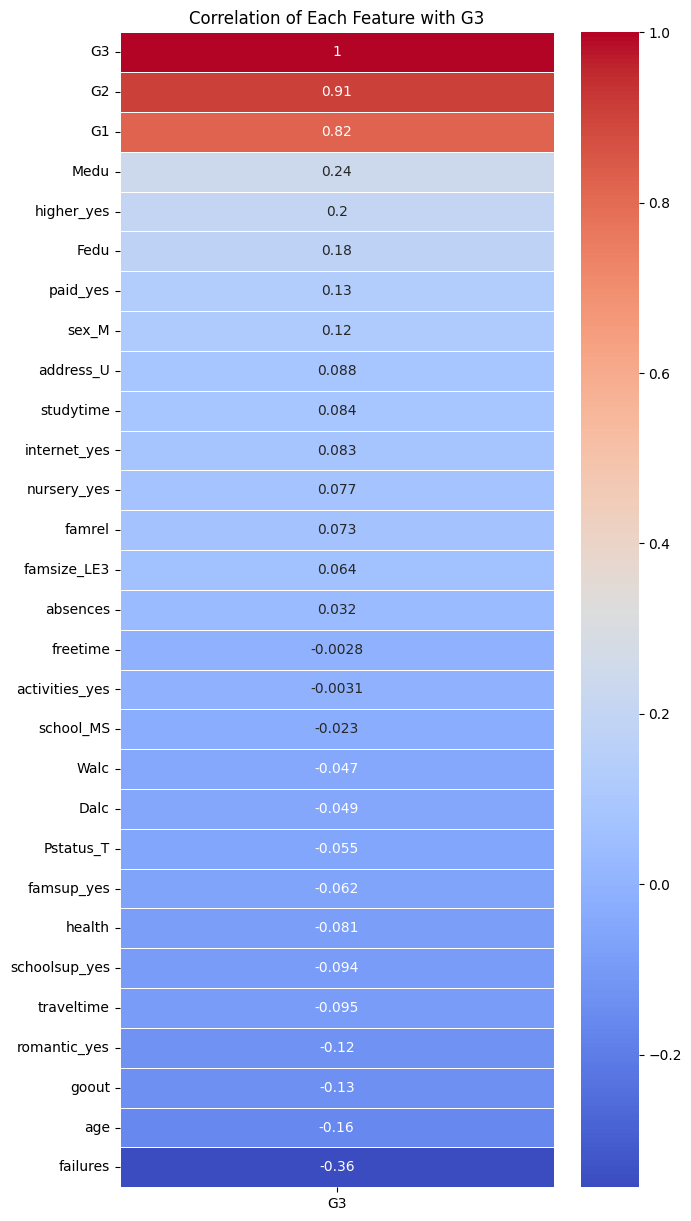

In [10]:
import seaborn as sn
# Insert your code here
# Compute the correlation matrix for all features
corr_matrix = df_numerical.corr()

# Plot a heatmap showing ONLY correlations with G3 (sorted)
plt.figure(figsize=(7, 15))
sn.heatmap(
    corr_matrix[["G3"]].sort_values(by="G3", ascending=False),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation of Each Feature with G3")
plt.show()

#### Food for thought:
*What can you learn from this test? Are all input parameters equally important? Which ones could you omit? Which two variables are the best predictor of student performance at the end of the year and why?*

## 2. Linear Regression

The first task you are going to tackle is Linear regression. In this task we will predict a student's performance according to their different parameters.

### 2.1 Fit a linear model

You can use the LinearRegression class from sklearn.linear_model. You can read more on it at:

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

In [11]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()

# Insert your code here
reg.fit(train_x, train_s)

LinearRegression()

### 2.2 Test the accuracy of the model

There are several ways to measure the accuracy of a linear regression model. Test your model using the '[predict](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)' function on the test set. You can measure the accuracy using MSE:

$MSE= \frac 1N\sum(s-\hat{s})^2$

or using the $R^2$ value:

$1-\frac{\text{unexplained variance=MSE}}{\text{Total Variation}}=1-\frac{\sum(s-\hat{s})^2}{\sum(s-\bar{s})^2}$

You can read on it further [here](https://en.wikipedia.org/wiki/Coefficient_of_determination).

In [12]:
# Insert your code here
from sklearn.metrics import  mean_squared_error, r2_score
test_prediction = reg.predict(test_x)
mse = mean_squared_error(test_s, test_prediction)
r2 = r2_score(test_s, test_prediction)

print("MSE: ", mse)
print("R^2: ", r2)

MSE:  0.3868349447593284
R^2:  0.7442032881008911


If everything went correctly you should get an MSE value of around 0.11 and around 0.87 for $R^2$.

### 2.3 Save the parameters of the model

Run the code block below to see your model's coefficients and intercept. These values will be used for grading, so make sure they are correct.

In [13]:
coef = reg.coef_
intrcpt = reg.intercept_
print("coefficients: ")
print(coef)
print("intercept: ")
print(intrcpt)

coefficients: 
[-2.08117210e-02  3.28304299e-02 -6.55761419e-03  3.67049263e-02
  6.84896679e-04 -1.25245820e-02  5.23934714e-02 -2.28974029e-02
  3.82768373e-02 -4.20585337e-02 -8.39601094e-03 -3.58429802e-03
  8.45486537e-02  9.34855882e-02  8.48477292e-01  5.18556417e-03
  3.52489821e-02  9.40689981e-04  1.75210540e-02  9.39914469e-03
  2.93622840e-02 -7.12328135e-03  2.87212899e-03 -4.18342790e-02
 -3.07596960e-02 -4.55726429e-04 -3.29387289e-02 -4.93300026e-02]
intercept: 
-6.891577337666913e-17


### 2.4 Test your skills in Linear algebra and compare the result to sklearn

While using Sklearn's built in linear regression is easy it is also important to see that it is not too complicated to write the regression by yourself. In class you were taught that the linear regression could be estimated using the Least Squares method. The Pseudo-Inverse is defined as:

$\theta^* = (X^TX)^{-1}X^Ts$

Use this knowledge to write the linear regression yourself. Implement the LeastSquares function in the cell below.

In this function you are not allowed to use the sklearn or scipy libraries.

In [14]:
def LeastSquares(X, y):
  '''
    Calculates the Least squares solution to the problem X*theta=y using the least squares method
    :param X: numpy input matrix, size [N,m+1] (feature 0 is a column of 1 for bias)
    :param y: numpy input vector, size [N]
    :return theta = (Xt*X)^(-1) * Xt * y: numpy output vector, size [m+1]
    N is the number of samples and m is the number of features=28
  '''
  # Insert your code here

  # (X^TX)
  XtX = X.T @ X
  # (X^TX)^(-1)
  XtX_inv = np.linalg.inv(XtX)
  # X^Ty
  Xty = X.T @ y

  # Theta = [(X^TX)^(-1)][X^Ty]
  theta = XtX_inv @ Xty

  return theta

In [15]:
import scipy

from copy import deepcopy
train_x_tag = np.hstack([np.ones([train_x.shape[0],1]),train_x]) # we add the bias term directly to the linear equation
theta = LeastSquares(train_x_tag,train_s)

Test the accuracy of the model, as in 2.2

In [16]:
# Prepare test matrix with bias term
test_x_tag = np.hstack([np.ones([test_x.shape[0], 1]), test_x])

# Predict using theta
y_pred_ls = test_x_tag @ theta

# Compute MSE
mse_ls = np.mean((test_s - y_pred_ls) ** 2)

# Compute R^2
ss_res = np.sum((test_s - y_pred_ls) ** 2)
ss_tot = np.sum((test_s - np.mean(test_s)) ** 2)
r2_ls = 1 - ss_res / ss_tot

print("Least Squares MSE:", mse_ls)
print("Least Squares R^2:", r2_ls)

Least Squares MSE: 0.3868349447593289
Least Squares R^2: 0.7442032881008908


## 3. Linear Classification

In this section you will be classifying whether a student's performance in the end of the year was above average or not according to all other metrics.

### 3.1 Prepare the data: split the dataset between students with grades above average and below and then split again for train test

To set up our data for classification, we'll use the "G3" field to represent whether a student achieved a performance above average or below. In our case `df_cl["G3"]` will be 1 if the student's performance is above average and 0 otherwise.

In [17]:
df_cl = deepcopy(df_numerical)
print("average performance = "+ str(df_cl['G3'].mean()))
df_cl["G3"] = df["G3"].map(lambda x: int(x > 10))

average performance = 10.494117647058824


Next you need to normalize and split the dataframe into a training and test sets just like was done in part 1.2.

**Notice that when normalizing you do not normalize the labels**

In [18]:
# Insert your code here for normalizing and splitting the dataset for train and test

# Split dataset (df_cl)
df_cl_train = df_cl[:270]
df_cl_test  = df_cl[270:]


train_cl_s = df_cl_train["G3"].to_numpy()
test_cl_s = df_cl_test["G3"].to_numpy()

train_features = df_cl_train.drop("G3", axis=1)
test_features  = df_cl_test.drop("G3", axis=1)

feature_means = train_features.mean().to_numpy()
feature_stds  = train_features.std().to_numpy()
feature_stds[feature_stds == 0] = 0.01

train_cl_x = (train_features - feature_means) / feature_stds
test_cl_x = (test_features  - feature_means) / feature_stds

train_cl_x = train_cl_x.to_numpy()
test_cl_x  = test_cl_x.to_numpy()

### 3.2 Fit an SVM model to the data to predict whether a grade is above or below average

Read on [the svm implementation of sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html). Fit the model on the training classification dataset you built.

In [19]:
import sklearn.svm
svc = sklearn.svm.LinearSVC()

# Insert your code here:
svc.fit(train_cl_x, train_cl_s)

LinearSVC()

### 3.3 Test your model

For classification accuracy is usually calculated as the number of correct predictions divided by number of total predictions:

$$\frac{\text{Number of correct predictions}}{\text{Number of total predictions}}$$

The accuracy is calculated on the test set. Implement the accuracy function in the cell below and run the test after it:

In [20]:
def classification_accuracy(model, X, s):
  '''
    calculate the accuracy for the classification problem
    :param model: the classification model class
    :param X: numpy input matrix, size [N,m]
    :param s: numpy input vector of ground truth labels, size [N]
    :return: accuracy of the model = (correct classifications)/(total classifications) type float
    N is the number of samples and m is the number of features=28
  '''
  # Insert your code here
  # 1. Generate predictions from the model using the input features (X).
  # The model.predict(X) function outputs an array of decisions (0 or 1).
  predictions = model.predict(X)

  # 2. Compare the predictions to the ground truth labels (s).
  # (predictions == s) creates a boolean array (True/False).
  # np.sum counts the number of True values (True = 1, False = 0), giving us the count of correct predictions.
  correct_predictions = np.sum(predictions == s)

  # 3. Calculate Accuracy
  total_predictions = len(s) # Total number of samples in the test set.
  accuracy = correct_predictions / total_predictions
  return accuracy

In [21]:
classification_accuracy(svc,test_cl_x,test_cl_s)

np.float64(0.8857142857142857)

If everything worked correctly you should get an accuracy of around 90%

### 3.4 Save the parameters of the model

Run the code block below to see your model's coefficients, intercept, and classes. These values will be used for grading, so make sure they are correct.

In [22]:
coef_cl = svc.coef_
intrcpt_cl = svc.intercept_
classes_cl = svc.classes_
print(coef_cl)
print(intrcpt_cl)
print(classes_cl)

[[-0.3033753  -0.02918069  0.1742696  -0.17555627 -0.38050142 -0.41475147
  -0.01134382 -0.17906412  0.05956022  0.03257893 -0.62060333 -0.09851479
   0.20793393  0.99878533  3.00555263 -0.53366383 -0.07675817 -0.2207052
  -0.06444022  0.00713032  0.06330016  0.06701433  0.01992979 -0.48674502
  -0.3937853   0.01436065  0.10928911  0.44580284]]
[0.58874004]
[0 1]


---
# Part 2. Music Century Classification

## 1. Data

*Make* sure you have the `YearPredictionMSD.csv` dataset from the moodle in the same directory in your Google Drive as you set earlier.

In [23]:
csv_path = drive_path + 'YearPredictionMSD.csv'
t_label = ["year"]
x_labels = ["var%d" % i for i in range(1, 91)]
df2 = pandas.read_csv(csv_path)

Now that the data is loaded to your Colab notebook, you should be able to display the Pandas DataFrame `df2` as a table:

In [24]:
df2

,year,var1,var2,var3,var4,var5,var6,var7,var8,var9,...,var81,var82,var83,var84,var85,var86,var87,var88,var89,var90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
508710,1979,42.88385,-17.41629,-13.51726,-0.75243,4.74785,14.33437,-11.75670,-10.46058,-14.91937,...,-23.01045,-169.62524,43.90683,15.45299,2.84499,94.83469,-157.26665,3.60034,54.26775,-22.24375
508711,2010,42.47120,13.16539,-6.89795,14.78750,14.72776,-12.05820,-6.56437,-7.70141,-8.01135,...,6.97510,97.98602,-45.39312,-30.26953,-9.49116,-51.58060,-12.08770,0.10696,117.82374,-1.06577
508712,2010,45.21104,-19.03522,-16.50919,19.30722,-22.23290,-25.77296,15.66504,-3.26132,1.78980,...,17.64373,27.46728,48.64159,92.03877,11.31597,-189.77886,179.06219,-3.74635,-27.01421,-10.23084
508713,2004,44.60991,29.26510,-14.79970,16.26654,-20.44287,34.93228,-8.15282,2.94035,-1.93460,...,21.30827,-183.32526,-40.60815,19.53727,12.13429,-133.10456,-158.46478,22.36919,161.58392,-18.54131


To set up our data for classification, we'll use the "year" field to represent whether a song was released in the 21st century. In our case `df2["year"]` will be 1 if the year was released after 2000, and 0 otherwise.

In [25]:
df2["year"] = df2["year"].map(lambda x: int(x > 2000))

In [26]:
df2.head(20)

,year,var1,var2,var3,var4,var5,var6,var7,var8,var9,...,var81,var82,var83,var84,var85,var86,var87,var88,var89,var90
0,1,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,1,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,1,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,1,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,1,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903
5,1,50.54767,0.31568,92.35066,22.38696,-25.51870,-19.04928,20.67345,-5.19943,3.63566,...,6.59753,-50.69577,26.02574,18.94430,-0.33730,6.09352,35.18381,5.00283,-11.02257,0.02263
6,1,50.57546,33.17843,50.53517,11.55217,-27.24764,-8.78206,-12.04282,-9.53930,28.61811,...,11.63681,25.44182,134.62382,21.51982,8.17570,35.46251,11.57736,4.50056,-4.62739,1.40192
7,1,48.26892,8.97526,75.23158,24.04945,-16.02105,-14.09491,8.11871,-1.87566,7.46701,...,18.03989,-58.46192,-65.56438,46.99856,-4.09602,56.37650,-18.29975,-0.30633,3.98364,-3.72556
8,1,49.75468,33.99581,56.73846,2.89581,-2.92429,-26.44413,1.71392,-0.55644,22.08594,...,18.70812,5.20391,-27.75192,17.22100,-0.85210,-15.67150,-26.36257,5.48708,-9.13495,6.08680
9,1,45.17809,46.34234,-40.65357,-2.47909,1.21253,-0.65302,-6.95536,-12.20040,17.02512,...,-4.36742,-87.55285,-70.79677,76.57355,-7.71727,3.26926,-298.49845,11.49326,-89.21804,-15.09719


### 1.1 - Train Test Split

The data set description text asks us to respect the below train/test split to avoid the "producer effect". That is, we want to make sure that no song from a single artist ends up in both the training and test set.

#### Food for thought:
Why would it be problematic to have some songs from an artist in the training set, and other songs from the same artist in the test set? (Hint: Remember that we want our test accuracy to predict how well the model will perform in practice on a song it hasn't learned about.)

In [27]:
# train test split
df_train = df2[:463715]
df_test = df2[463715:]

# convert to numpy
train_xs = df_train[x_labels].to_numpy()
train_ts = df_train[t_label].to_numpy()
test_xs = df_test[x_labels].to_numpy()
test_ts = df_test[t_label].to_numpy()

### 1.2 Normalizing the Dataset

Normalize the data by subtracting the mean and dividing by the std just like in Part 1.

In [28]:
# Insert your code here:
feature_means = train_xs.mean(axis=0)
feature_stds  = train_xs.std(axis=0)

train_norm_xs = (train_xs - feature_means) / feature_stds
test_norm_xs = (test_xs - feature_means) / feature_stds

### 1.3 Splitting the Dataset

Finally, we'll move some of the data in our training set into a validation set.

#### Food for thought:
Why should we limit how many times we use the test set, and how do we use the validation set during the model building process?

In [29]:
# shuffle the training set
reindex = np.random.permutation(len(train_xs))
train_xs = train_xs[reindex]
train_norm_xs = train_norm_xs[reindex]
train_ts = train_ts[reindex]

# use the first 50000 elements of `train_xs` as the validation set
train_xs, val_xs           = train_xs[50000:], train_xs[:50000]
train_norm_xs, val_norm_xs = train_norm_xs[50000:], train_norm_xs[:50000]
train_ts, val_ts           = train_ts[50000:], train_ts[:50000]

## 2. Classification

We will now build a *classification* model to perform decade classification. We have written a few helper functions for you below (`sigmoid`, `cross_entropy` and `get_accuracy`). All other code that you write in this section should be vectorized whenever possible (i.e., avoid unnecessary loops). Feel free to add more testing to the notebook to validate your code.

In [30]:
def sigmoid(z):
  return 1 / (1 + np.exp(-z))

def cross_entropy(t, y):
  return -t * np.log(y) - (1 - t) * np.log(1 - y)

def get_accuracy(y, t):
  acc = 0
  N = 0
  for i in range(len(y)):
    N += 1
    if (y[i] >= 0.5 and t[i] == 1) or (y[i] < 0.5 and t[i] == 0):
      acc += 1
  return acc / N

### 2.1 Prediction

Implement the function `pred` in the cell below that computes the prediction `y` based on logistic regression, i.e., a single layer with weights `w` and bias `b`. The output is given by:

\begin{equation}
y = \sigma({\bf w}^T {\bf x} + b),
\end{equation}

where the value of $y$ is an estimate of the probability that the song is released in the current century, namely ${\rm year} =1$.

In [31]:
def pred(w, b, X):
  """
  Returns the prediction `y` of the target based on the weights `w` and scalar bias `b`.

  Preconditions: np.shape(w) == (90,)
                 type(b) == float
                 np.shape(X) = (N, 90) for some N
  Postconditions: np.shape(y)==(N,)

  >>> pred(np.zeros(90), 1, np.ones([2, 90]))
  array([0.73105858, 0.73105858]) # It's okay if your output differs in the last decimals
  """
  # Insert your code here
  # Calculate z = X @ w + b
  z = X @ w + b

  # Applying the sigmoid function elementwise on z to get y
  y = sigmoid(z)
  return y

In [32]:

pred(np.zeros(90), 1, np.ones([2, 90]))

array([0.73105858, 0.73105858])

### 2.2 Cost

Assuming the loss function is the cross entropy function, implement the cost(risk) function in the cell below which returns the mean of the loss function on all inputs.

$$\mathcal{L}_\mathcal{P}(\text{Cross Entropy}) = \mathbb{E}_{(y,t)\sim\mathcal{P}}\left\{\text{CE}(t,s)\right\}$$

In [33]:
def cost(y, t):
  """
  Returns the cost(risk function) `L` of the prediction 'y' and the ground truth 't'.

  - parameter y: prediction
  - parameter t: ground truth
  - return L: cost/risk
  Preconditions: np.shape(y) == (N,) for some N
                 np.shape(t) == (N,)

  Postconditions: type(L) == float
  >>> cost(0.5*np.ones(90), np.ones(90))
  0.69314718 # It's okay if your output differs in the last decimals
  """
  # Insert your code here

  # Using the cross-entropy function defined earlier
  CE = cross_entropy(t, y)

  # Computes the model's cost as the average cross-entropy over all samples
  L = np.mean(CE)
  return L

In [34]:
print(cost(0.5*np.ones(4), np.ones(4)))

0.6931471805599453


### 2.3 Derivative of the cost

Take a pen and paper and calculate the analytical derivative of the cost function with respect to the weights and bias. Use the formula calculated to implement the function `derivative_cost` in the cell below that computes and returns the gradients $\frac{\partial\mathcal{L}}{\partial {\bf w}}$ and $\frac{\partial\mathcal{L}}{\partial b}$. Here, `X` is the input, `y` is the prediction, and `t` is the true label.

In [35]:
def derivative_cost(X, y, t):
  """
  Returns a tuple containing the gradients dLdw and dLdb.

  Precondition: np.shape(X) == (N, 90) for some N
                np.shape(y) == (N,)
                np.shape(t) == (N,)

  Postcondition: np.shape(dLdw) = (90,)
           type(dLdb) = float
           return dLdw,dldb
  """
  # Insert your code here
  """
  Computes the analytical gradients of the logistic regression cost function
  with respect to the weights w and bias b.

  Mathematical derivation:
  Prediction:
      y = sigmoid(z),   where  z = w^T x + b

  Cross-entropy loss for one sample:
      CE = −[ t*log(y) + (1−t)*log(1−y) ]

  Total loss (mean over all N samples):
      L = (1/number_of_samples) * Σ CE_i

  Using the chain rule and the derivative of the sigmoid:
      dCE_i/dz_i = (y_i − t_i)

  Gradients:
      dL/dw = (1/number_of_samples) * X^T (y − t)
      dL/db = (1/number_of_samples) * Σ (y_i − t_i)

  Returns:
      dLdw : gradient by w
      dLdb : gradient by b
  """

  # get number of samples
  number_of_samples = X.shape[0]
  # calculate error
  diff = y - t

  dLdw = (X.T @ diff) / number_of_samples
  dLdb = diff.mean()

  return (dLdw, dLdb)

In [36]:
dldw, dldb = derivative_cost(np.ones([10,90]), np.ones(10), np.ones(10))
print(dldw.shape)
print(type(dldb))

(90,)
<class 'numpy.float64'>


### 2.4 Derivative approximation

We can check that our derivative is implemented correctly using the finite difference rule. In 1D, the finite difference rule tells us that for small $h$, we should have

$$\frac{f(x+h) - f(x)}{h} \approx f'(x)$$

Make sure that $\frac{\partial\mathcal{L}}{\partial b}$ is implemented correctly by comparing the result from `derivative_cost` with the empirical cost derivative computed using the above numerical approximation.

In [37]:
# Your code goes here
'''
r1 = ...
r2 = ...
print("The analytical results is -", r1)
print("The algorithm results is - ", r2)
'''
w_test = np.zeros(90)
b_test = 0.5
h = 1e-6

X_test = train_norm_xs[0:100]
t_test = train_ts[0:100, 0]

dLdw_test, dLdb_test = derivative_cost(X_test, pred(w_test, b_test, X_test), t_test)
r1 = dLdb_test

y_base = pred(w_test, b_test, X_test)
cost_base = cost(y_base, t_test)

y_plus_h = pred(w_test, b_test + h, X_test)
cost_plus_h = cost(y_plus_h, t_test)

r2 = (cost_plus_h - cost_base) / h

print("The analytical results is -", r1)
print("The algorithm results is - ", r2)

The analytical results is - 0.05245933120185457
The algorithm results is -  0.052459449007002945


Make sure that $\frac{\partial\mathcal{L}}{\partial {\bf w}}$ is implemented correctly.

In [38]:
# Your code goes here. You might find this below code helpful: but it's
# up to you to figure out how/why, and how to modify the code

'''
r1 = ...
r2 = ...
print("The analytical results is -", r1)
print("The algorithm results is - ", r2)
'''
# Assuming w_test, b_test, h, X_test, and t_test are defined from the previous cell.

# --- 1. Analytical Gradient (Your implementation) ---

# Calculate the full vector of analytical gradients (dLdw_alg and dLdb_alg)
dLdw_alg, dLdb_alg = derivative_cost(X_test, pred(w_test, b_test, X_test), t_test)

# Extract the gradient for the first weight (w[0]). This is r1.
r1 = dLdw_alg[0] # This is the analytical result for dL/dw[0]


# --- 2. Numerical Gradient (The Approximation) ---

# Create a copy of the test weights and add the small step 'h' ONLY to the first weight (w[0]).
w_plus_h = w_test.copy()
w_plus_h[0] += h # Perturb (change) only the first weight by 'h'

# A. Calculate the Cost at the original point (f(w))
y_base = pred(w_test, b_test, X_test)
cost_base = cost(y_base, t_test)

# B. Calculate the Cost at the perturbed point (f(w+h))
y_plus_h = pred(w_plus_h, b_test, X_test)
cost_plus_h = cost(y_plus_h, t_test)

# C. Calculate the numerical approximation: [f(w+h) - f(w)] / h
# This is the numerical gradient for w[0].
r2 = (cost_plus_h - cost_base) / h # This is the numerical result

print("The analytical results is -", r1)
print("The algorithm results is - ", r2)

The analytical results is - -0.1743162437925806
The algorithm results is -  -0.1743161204270649


### 2.5 Gradient descent

Now that you have a gradient function that works, we can actually run gradient descent. Complete the following code that will run stochastic gradient descent training:

In [39]:
def run_gradient_descent(w0, b0, mu=0.1, batch_size=100, max_iters=100):
  """Return the values of (w, b) after running gradient descent for max_iters.
  We use:
    - train_norm_xs and train_ts as the training set
    - val_norm_xs and val_ts as the test set
    - mu as the learning rate
    - (w0, b0) as the initial values of (w, b)

  Precondition: np.shape(w0) == (90,)
                type(b0) == float

  Postcondition: np.shape(w) == (90,)
                 type(b) == float
  """
  w = w0
  b = b0
  iter = 0
  max_acc = 0
  opt_w = w.copy()
  opt_b = b
  cost_list = []
  acc_list  = []

  # Ensure the training data is accessible and can be shuffled locally (Fix for UnboundLocalError)
  # We make local references to the global data arrays for shuffling
  local_train_norm_xs = train_norm_xs
  local_train_ts = train_ts
  local_val_X = val_norm_xs
  local_val_t = val_ts[:, 0]

  while iter < max_iters:
    # shuffle the training set (there is code above for how to do this)
    # <===
    reindex = np.random.permutation(len(local_train_norm_xs))
    local_train_norm_xs = local_train_norm_xs[reindex]
    local_train_ts = local_train_ts[reindex]

    for i in range(0, len(train_norm_xs), batch_size): # iterate over each minibatch
      # minibatch that we are working with:
      X = train_norm_xs[i:(i + batch_size)]
      t = train_ts[i:(i + batch_size), 0]

      # since len(train_norm_xs) does not divide batch_size evenly, we will skip over
      # the "last" minibatch
      if np.shape(X)[0] != batch_size:
        continue

      # compute the prediction
      # <===
      y = pred(w, b, X)

      # calculate gradient(backpropegate)
      # <===
      dLdw, dLdb = derivative_cost(X, y, t)

      # update w and b(step)
      # <===
      w = w - mu * dLdw
      b = b - mu * dLdb

      # increment the iteration count
      iter += 1
      # compute and print the *validation* loss and accuracy
      if (iter % 40 == 0):
        # <===
        val_y = pred(w, b, local_val_X)

        val_cost = cost(val_y, local_val_t)
        val_acc = get_accuracy(val_y, local_val_t)

        cost_list.append(val_cost)
        acc_list.append(val_acc)
        # save the best weights and biases
        if val_acc>max_acc:
          max_acc = val_acc
          opt_w = w.copy()
          opt_b = b

        print("Iter %d. [Val Acc %.0f%%, Loss %f]" % (
              iter, val_acc * 100, val_cost))

      if iter >= max_iters:
        break


  return opt_w, opt_b, cost_list, acc_list

### 2.6 Running everything!

Call `run_gradient_descent` with the weights and biases all initialized to zero. Test yourself with different $\mu$ values and show that if mu is too small then convergence is slow and if mu is too large then the optimization algorithm does not converge. You can add more automation and plot functions to help you find the best configuration.

Iter 40. [Val Acc 68%, Loss 0.630488]
Iter 80. [Val Acc 70%, Loss 0.611259]
Iter 120. [Val Acc 70%, Loss 0.600879]
Iter 160. [Val Acc 71%, Loss 0.593194]
Iter 200. [Val Acc 71%, Loss 0.587996]
Iter 240. [Val Acc 72%, Loss 0.582924]
Iter 280. [Val Acc 72%, Loss 0.579130]
Iter 320. [Val Acc 72%, Loss 0.577196]
Iter 360. [Val Acc 72%, Loss 0.574542]
Iter 400. [Val Acc 72%, Loss 0.572827]
Iter 440. [Val Acc 72%, Loss 0.570382]
Iter 480. [Val Acc 72%, Loss 0.571093]
Iter 520. [Val Acc 73%, Loss 0.568857]
Iter 560. [Val Acc 73%, Loss 0.566419]
Iter 600. [Val Acc 73%, Loss 0.565968]
Iter 640. [Val Acc 72%, Loss 0.565976]
Iter 680. [Val Acc 72%, Loss 0.568217]
Iter 720. [Val Acc 73%, Loss 0.564400]
Iter 760. [Val Acc 73%, Loss 0.564616]
Iter 800. [Val Acc 73%, Loss 0.564679]
Iter 840. [Val Acc 72%, Loss 0.565498]
Iter 880. [Val Acc 73%, Loss 0.564530]
Iter 920. [Val Acc 72%, Loss 0.565294]
Iter 960. [Val Acc 73%, Loss 0.562708]
Iter 1000. [Val Acc 73%, Loss 0.563536]
Iter 1040. [Val Acc 73%, L

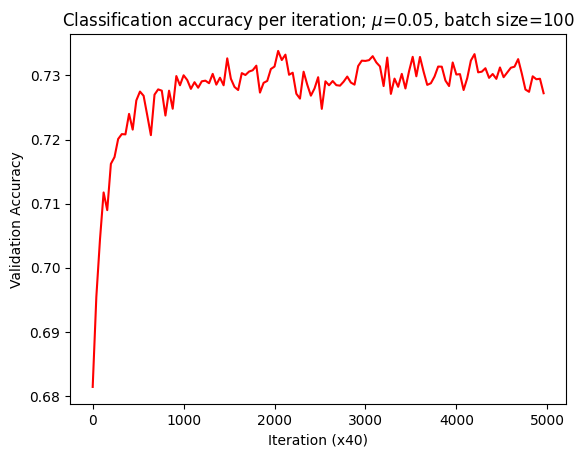

In [40]:
w0 = np.zeros(90)
b0 = np.zeros(1)[0]

# choose values
mu = 0.05
max_iters = 5000
batch_size = 100


# Write your code here
opt_w, opt_b, cost_list, acc_list = run_gradient_descent(w0, b0, mu, batch_size, max_iters)

# Plotting the results (as suggested in the comments)
plt.plot(range(0, max_iters, 40), acc_list, "r-")
plt.title(f"Classification accuracy per iteration; $\\mu$={mu}, batch size={batch_size}")
plt.xlabel("Iteration (x40)")
plt.ylabel("Validation Accuracy")
plt.show()

### 2.7 Results

Using the optimal values of `w` and `b` from part 2.6, compute your training accuracy, validation accuracy, and test accuracy. Are there any differences between those three values? If so, why?

In [41]:
# Use the optimal w and b from part 2.6
# Write your code here

# Calculate predictions on the training set
train_y = pred(opt_w, opt_b, train_norm_xs)
train_acc = get_accuracy(train_y, train_ts[:, 0])

# Calculate predictions on the validation set
val_y = pred(opt_w, opt_b, val_norm_xs)
val_acc = get_accuracy(val_y, val_ts[:, 0])

# Calculate predictions on the final, unseen test set
test_y = pred(opt_w, opt_b, test_norm_xs)
test_acc = get_accuracy(test_y, test_ts[:, 0])

print('train_acc = ', train_acc, ' val_acc = ', val_acc, ' test_acc = ', test_acc)

train_acc =  0.7336910675223282  val_acc =  0.73382  test_acc =  0.7300888888888889


### 2.8 Using PyTorch

Writing a classifier like this is instructive, and helps you understand what happens when we train a model. However, in practice, we rarely write model building and training code from scratch. Instead, we typically use one of the well-tested libraries available in a package. The following example shows you how this task could have been achieved using the deep learning library, PyTorch. The library greatly simplifies the steps needed to create a learning model. Though there is nothing you need to complete in this section we suggest you read this section thoroughly and make sure you understand all the code. In the next assignment you will need to build a deep learning model yourself.

The first step required to use the PyTorch module is to create a class which will be our model. In this case we will use a linear layer with a custom size (in your assignment you used a 90,1 linear layer meaning an input size of 90 and an output size of 1). We also add a sigmoid function to restrict the values between 0 and 1.

The forward function is called every time you call the model by name. It is equivalent to the prediction function you wrote but it serves another purpose since it saves all the operations done to the tensor which can then be used to calculate the gradients.

In [42]:
import torch
class single_layer(torch.nn.Module):
  def __init__(self,input_size,output_size):
    super(single_layer,self).__init__()
    self.neuron = torch.nn.Linear(input_size,output_size)
    self.sigmoid = torch.nn.Sigmoid()

  def forward(self,X):
    out = self.neuron(X)
    out = self.sigmoid(out)
    return out

We can now create a new model.

We don't have to write the binary cross entropy loss since it is already written for us (criterion).

Also instead of writing the optimization process which in our case was gradient descent (W[n+1] = w[n]-$\mu$dL/dW) we can use a pre-built optimizer (SGD).

In [43]:
model = single_layer(90,1)
criterion = torch.nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(),lr = 0.05)

There are a few pre-built training functions but usually the training function is written by hand. This function is similar to the one you wrote in this assignment only we now can use the pre-built tensor functions. Make sure you understood all the differences between the two:

In [44]:
import pdb
def train_model(model, criterion, optimizer, batch_size=100, max_iters=100):
  iter = 0
  cost_list = []
  acc_list  = []
  train_norm_xs_shuff = train_norm_xs
  train_ts_shuff = train_ts
  val_X_tensor = torch.tensor(val_norm_xs,dtype=torch.float32)
  while iter < max_iters:
    # shuffle the training set (there is code above for how to do this)
    reindex = np.random.permutation(len(train_norm_xs))
    train_norm_xs_shuff = train_norm_xs_shuff[reindex]
    train_ts_shuff = train_ts_shuff[reindex]

    for i in range(0, len(train_norm_xs), batch_size): # iterate over each minibatch
      # minibatch that we are working with:
      X = train_norm_xs_shuff[i:(i + batch_size)]
      t = train_ts_shuff[i:(i + batch_size), 0]

      # since len(train_norm_xs) does not divide batch_size evenly, we will skip over
      # the "last" minibatch
      if np.shape(X)[0] != batch_size:
        continue
      # change the numpy types into torches tensors
      X_tensor = torch.tensor(X,dtype=torch.float32)
      t_tensor = torch.tensor(t,dtype=torch.float32).unsqueeze(1) # the unsqueeze reshapes (N,) to (N,1)

      # a clean up step for PyTorch
      optimizer.zero_grad()
      # compute the prediction
      prediction = model(X_tensor)
      # compute the cost/loss
      loss = criterion(prediction,t_tensor)
      # calculate gradient(backpropegate)
      loss.backward()
      # update w and b(step)
      optimizer.step()
      # increment the iteration count
      iter += 1
      # compute and print the *validation* accuracy
      if (iter % 40 == 0):
        val_pred = model(val_X_tensor)
        val_acc = get_accuracy(val_pred,val_ts)
        acc_list.append(val_acc)

        print("Iter %d. [Val Acc %.1f%%]" % (
                iter, val_acc * 100))

      if iter >= max_iters:
        break


  return acc_list

We can now run the training process. You should get pretty similar results to the ones from the model you wrote. Make sure that the results are in the same range and if not fix your model and try again.

In [45]:
acc_list = train_model(model,criterion,optimizer,100,500)

Iter 40. [Val Acc 66.2%]
Iter 80. [Val Acc 69.0%]
Iter 120. [Val Acc 70.0%]
Iter 160. [Val Acc 70.7%]
Iter 200. [Val Acc 71.2%]
Iter 240. [Val Acc 71.6%]
Iter 280. [Val Acc 71.8%]
Iter 320. [Val Acc 71.7%]
Iter 360. [Val Acc 71.9%]
Iter 400. [Val Acc 72.1%]
Iter 440. [Val Acc 72.2%]
Iter 480. [Val Acc 71.9%]


You can also try to change the model (add layers or change layers) change the optimizer or the hyperparameters and try to improve the validation accuracy. If you want a challenge you can try to reach a validation accuracy of 75%